In [1]:
#IMPORT MODULES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#LOAD DATASET

DATA_PATH = "./student_performance_dataset.csv"
df = pd.read_csv(DATA_PATH)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
#1. DATASET OVERVIEW

print("Dataset Shape:\n")
print(df.shape)

print("\nNumber of Rows:\n")
print(df.shape[0])

print("\nNumber of Columns:\n")
print(df.shape[1])

print("\nColumn Names:\n")
print(df.columns.tolist())

Dataset Shape:

(1000, 12)

Number of Rows:

1000

Number of Columns:

12

Column Names:

['student_id', 'gender', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'previous_grade', 'final_exam_score', 'final_grade']


In [4]:
#2. DATASET PREVIEW

print("First 5 Rows:\n")
display(df.head())

print("\nRandom Sample:\n")
display(df.sample(5, random_state=42))

First 5 Rows:



,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D



Random Sample:



,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
521,522,Male,4.6,73.7,5.4,PhD,No,Yes,Yes,74.8,71.8,C
737,738,Male,1.8,82.4,6.4,High School,Yes,No,Yes,70.9,66.6,D
740,741,Male,4.0,73.2,4.5,High School,Yes,No,No,49.4,62.9,D
660,661,Female,4.5,85.0,8.2,Bachelors,Yes,No,No,71.9,95.2,A
411,412,Female,4.5,77.0,4.7,High School,Yes,No,No,81.6,90.2,A


In [5]:
#3. DATASET INFORMATION

print("Dataset Info:\n")
df.info()

print("\nMissing Values:\n")
display(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nNumerical Statistics:\n")
display(df.describe())

Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 93.9 KB

Missing Values:



parental_education            102
student_id                      0
study_time_hours                0
gender                          0
attendance_percent              0
sleep_hours                     0
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64


Numerical Statistics:



,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [6]:
#4. SELECT REQUIRED FEATURES

selected_columns = ["sleep_hours", "final_grade"] 

selected_df = df[selected_columns]

print("Selected Feature Columns:\n")
display(selected_df.head())

Selected Feature Columns:



,sleep_hours,final_grade
0,6.5,A
1,5.7,A
2,7.9,A
3,8.0,B
4,4.6,D


In [7]:
#5. DROP UNNECESSARY COLUMNS


drop_columns = []

reduced_df = df.drop(columns=drop_columns, errors="ignore")

print("Reduced Dataset Shape:\n")
print(reduced_df.shape)

Reduced Dataset Shape:

(1000, 12)


In [8]:
#6. EXAMPLE FILTERING

numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) > 0:
    example_col = numeric_cols[0]
    filtered_df = df[
        df[example_col] > df[example_col].median()]

    print(f"\nFiltered rows using column: {example_col}")
    print(filtered_df.shape)


Filtered rows using column: student_id
(500, 12)


In [9]:
#7. CORRECTION ANALYSIS

numeric_df = df.select_dtypes(include=np.number)

if numeric_df.shape[1] > 1:
    corr = numeric_df.corr(numeric_only=True)
    print("Correlation Matrix:\n")
    display(corr.head())

Correlation Matrix:



,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
student_id,1.000000,0.027615,-0.044651,-0.012304,0.011917,0.025282
study_time_hours,0.027615,1.000000,-0.043712,0.005594,-0.035700,0.567513
attendance_percent,-0.044651,-0.043712,1.000000,0.034089,-0.014310,0.261872
sleep_hours,-0.012304,0.005594,0.034089,1.000000,0.000943,0.147811
previous_grade,0.011917,-0.035700,-0.014310,0.000943,1.000000,0.406327


Top Categories in: gender


/tmp/ipykernel_10963/1513001629.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


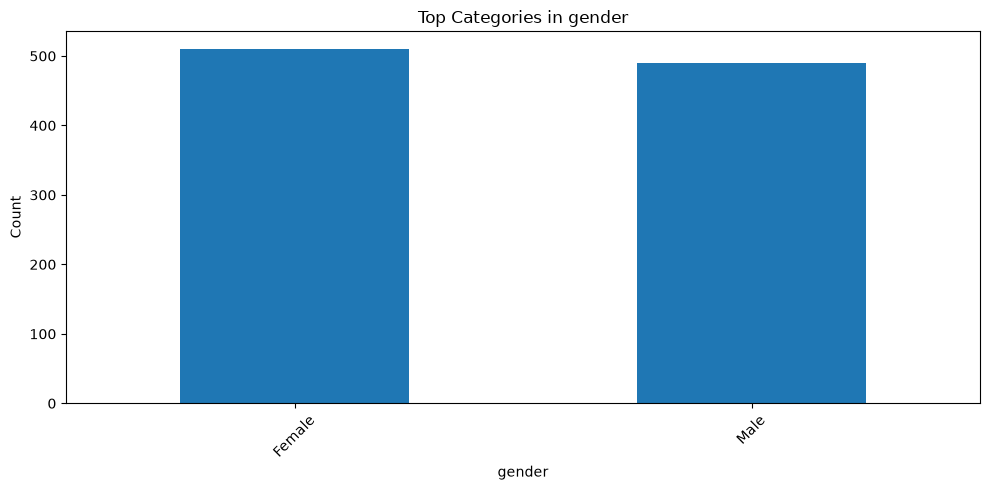

In [10]:
#8. CATEGORY DISTRIBUTION VISUALIZATION

categorical_cols = df.select_dtypes(include="object").columns

if len(categorical_cols) > 0:
    group_col = categorical_cols[0]
    top_categories = (df[group_col].value_counts().head(10))
    print(f"Top Categories in: {group_col}")

    plt.figure(figsize=(10, 5))
    top_categories.plot(kind="bar")
    plt.title(f"Top Categories in {group_col}")
    plt.xlabel(group_col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

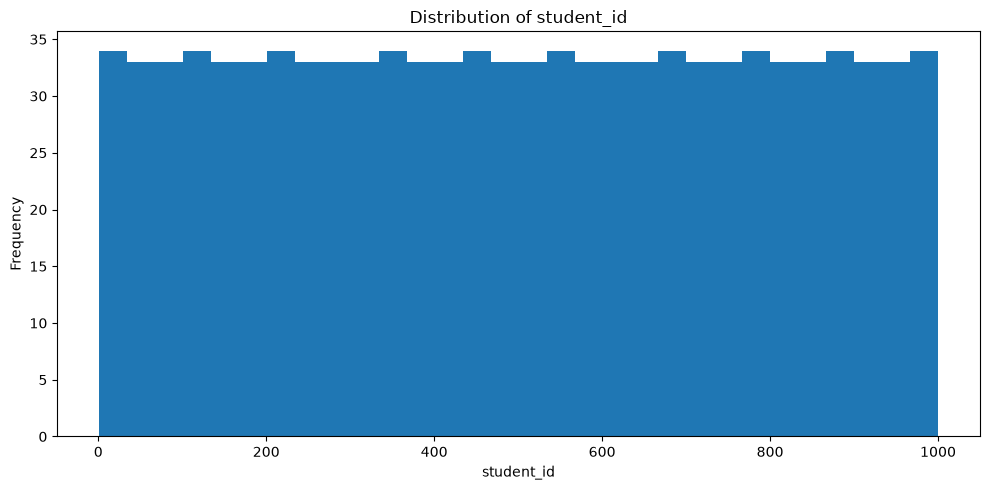

In [11]:
#9. NUMERIC DISTRIBUTION VISUALIZATION

if len(numeric_cols) > 0:
    hist_col = numeric_cols[0]
    plt.figure(figsize=(10, 5))
    plt.hist(df[hist_col].dropna(), bins=30)
    plt.title(f"Distribution of {hist_col}")
    plt.xlabel(hist_col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

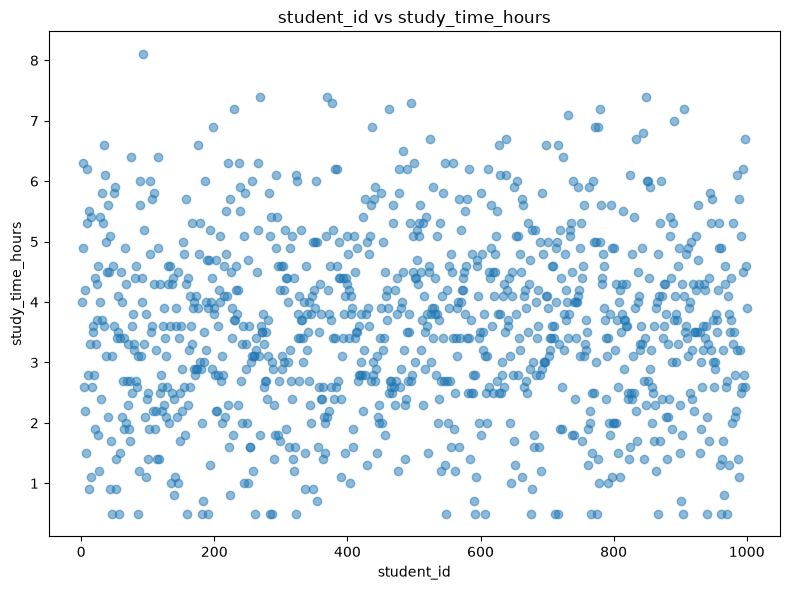

In [12]:
#10. SCATTER PLOT VISUALIZATION(EXAMPLE)

if len(numeric_cols) >= 2:
    x_col = numeric_cols[0]
    y_col = numeric_cols[1]

    sample_df = df[[x_col, y_col]].dropna().sample(min(5000, len(df)), random_state=42)

    plt.figure(figsize=(8, 6))
    plt.scatter(sample_df[x_col], sample_df[y_col], alpha=0.5)
    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

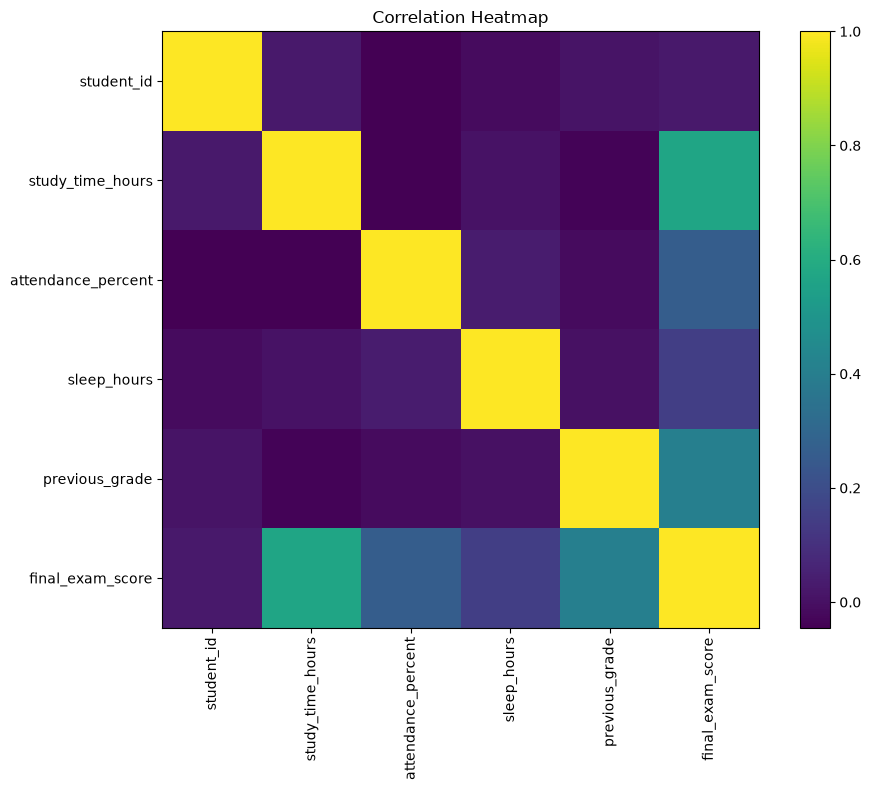

In [13]:
#11. CORRELATION HEATMAP

if numeric_df.shape[1] >= 2:
    corr_sample = numeric_df.iloc[:, :10].corr()

    plt.figure(figsize=(10, 8))
    plt.imshow(corr_sample)
    plt.colorbar()
    plt.xticks(range(len(corr_sample.columns)), corr_sample.columns, rotation=90)
    plt.yticks(range(len(corr_sample.columns)), corr_sample.columns)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

In [14]:
#12. TIME-SERIES VISUALIZATION
#NOTE: Must use only if dates exist.

date_cols = [col for col in df.columnsif "date" in col.lower() or "time" in col.lower()]

if len(date_cols) > 0 and len(numeric_cols) > 0:
    date_col = date_cols[0]
    value_col = numeric_cols[0]

    temp_df = df[[date_col, value_col]].copy()
    temp_df[date_col] = pd.to_datetime(temp_df[date_col], errors="coerce")
    temp_df = temp_df.dropna()
    temp_df = temp_df.sort_values(date_col)

    plt.figure(figsize=(12, 5))
    plt.plot(temp_df[date_col].head(500), temp_df[value_col].head(500))
    plt.title(f"{value_col} over Time")
    plt.xlabel("Date")
    plt.ylabel(value_col)
    plt.tight_layout()
    plt.show()

SyntaxError: invalid syntax (1569282843.py, line 4)

In [ ]:
#EXPORT DATASET

OUTPUT_PATH = ""
reduced_df.to_csv(OUTPUT_PATH, index=False)
print(f"\nProcessed dataset exported to:\n{OUTPUT_PATH}")